# Lesson 3.6 — Unsteady Flows and Time-Stepping

## When Does Time Matter?

Many engineering flows are **unsteady** — the solution changes meaningfully with time:
- Vortex shedding behind a cylinder (Lesson 2.7)
- Turbomachinery: rotor-stator interaction
- Aeroelastic flutter of wings
- Pulsatile blood flow in arteries
- Combustion instabilities

For steady RANS (SIMPLE): treat time as a relaxation parameter → drive to steady state.
For unsteady flows: the time integration must be accurate, not just stable.

---

## Time-Stepping Schemes

**Explicit Euler** (first-order):
$$u^{n+1} = u^n + \Delta t \, F(u^n)$$

**Second-order Adams-Bashforth** (explicit, 2nd order):
$$u^{n+1} = u^n + \Delta t \left( \frac{3}{2} F(u^n) - \frac{1}{2} F(u^{n-1}) \right)$$

**Crank-Nicolson** (implicit, 2nd order, unconditionally stable for diffusion):
$$u^{n+1} = u^n + \frac{\Delta t}{2} \left[ F(u^n) + F(u^{n+1}) \right]$$

**BDF2** (Backward Differentiation, implicit, 2nd order — used in OpenFOAM `backward` scheme):
$$\frac{3u^{n+1} - 4u^n + u^{n-1}}{2\Delta t} = F(u^{n+1})$$

**RK4** (explicit, 4th order — expensive but very accurate for smooth flows):
$$k_1 = F(u^n), \quad k_2 = F(u^n + \frac{\Delta t}{2}k_1), \ldots$$
$$u^{n+1} = u^n + \frac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

---

## Dual Time-Stepping

For implicit unsteady solvers (like PISO in OpenFOAM), an inner iteration loop converges
the solution at each physical time step. This is **dual time-stepping**:

- **Outer loop**: physical time $t$ (controlled by accuracy requirements)
- **Inner loop**: pseudo-time $\tau$ (driven to convergence using large $\Delta\tau$)

The physical time step $\Delta t$ can be large (accuracy-limited), while the pseudo-time
step $\Delta\tau$ is tuned for fast inner convergence.

---

## Choosing $\Delta t$: The Courant Number

For unsteady simulations, the Courant number must be $\leq 1$ for explicit schemes:

$$Co = \frac{|\mathbf{u}| \Delta t}{\Delta x} \leq 1$$

For implicit schemes, $Co$ can exceed 1 (unconditionally stable) but accuracy degrades.
For resolving flow features accurately: $Co < 0.5$ in the region of interest.


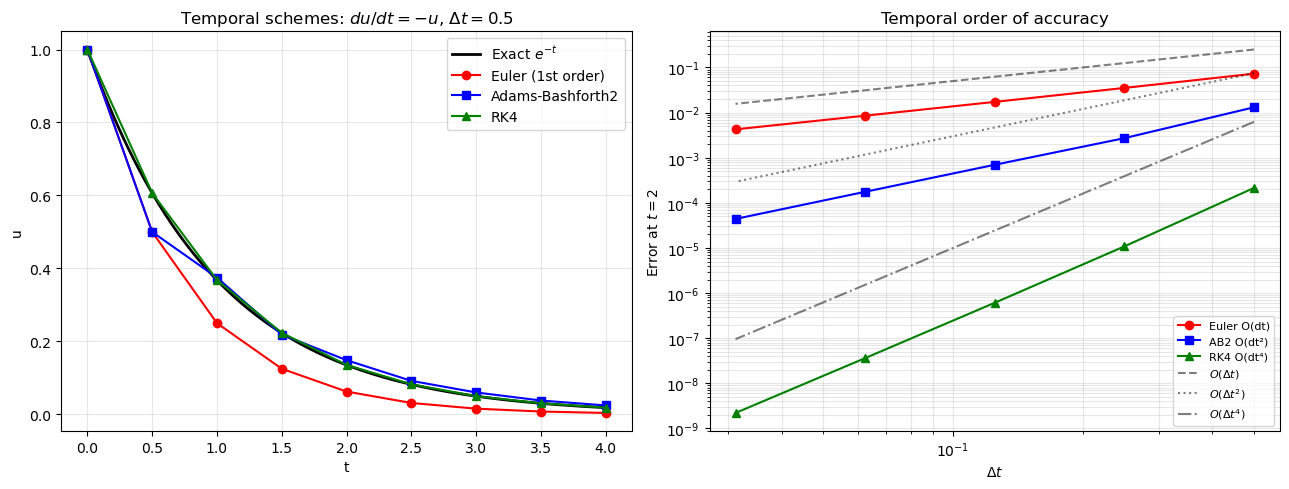

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Compare time-stepping schemes on 1D ODE: du/dt = -u (exponential decay)
# Exact: u(t) = exp(-t)

def euler_explicit(u0, dt, T):
    u, t = u0, 0.0
    us, ts = [u], [t]
    while t < T:
        u = u + dt*(-u)
        t += dt
        us.append(u); ts.append(t)
    return np.array(ts), np.array(us)

def adams_bashforth2(u0, dt, T):
    u, t = u0, 0.0
    F_old = -u0
    # First step: Euler
    u = u0 + dt*F_old
    t += dt
    us, ts = [u0, u], [0.0, t]
    while t < T:
        F_new = -u
        u_new = u + dt*(1.5*F_new - 0.5*F_old)
        F_old = F_new
        u = u_new
        t += dt
        us.append(u); ts.append(t)
    return np.array(ts), np.array(us)

def rk4(u0, dt, T):
    u, t = u0, 0.0
    us, ts = [u0], [0.0]
    while t < T:
        k1 = -u
        k2 = -(u + dt/2*k1)
        k3 = -(u + dt/2*k2)
        k4 = -(u + dt*k3)
        u = u + dt/6*(k1 + 2*k2 + 2*k3 + k4)
        t += dt
        us.append(u); ts.append(t)
    return np.array(ts), np.array(us)

T = 4.0
dt = 0.5  # fairly large step

t_exact = np.linspace(0, T, 200)
u_exact = np.exp(-t_exact)

t_eu, u_eu = euler_explicit(1.0, dt, T)
t_ab, u_ab = adams_bashforth2(1.0, dt, T)
t_rk, u_rk = rk4(1.0, dt, T)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(t_exact, u_exact, 'k-', linewidth=2, label='Exact $e^{-t}$')
axes[0].plot(t_eu, u_eu, 'r-o', markersize=6, label='Euler (1st order)')
axes[0].plot(t_ab, u_ab, 'b-s', markersize=6, label='Adams-Bashforth2')
axes[0].plot(t_rk, u_rk, 'g-^', markersize=6, label='RK4')
axes[0].set_xlabel('t'); axes[0].set_ylabel('u')
axes[0].set_title(f'Temporal schemes: $du/dt = -u$, $\\Delta t = {dt}$')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Convergence study
dt_vals = [0.5, 0.25, 0.125, 0.0625, 0.03125]
T_test  = 2.0
u_ref   = np.exp(-T_test)

errs_eu  = [abs(euler_explicit(1.0, dt, T_test)[1][-1] - u_ref) for dt in dt_vals]
errs_ab  = [abs(adams_bashforth2(1.0, dt, T_test)[1][-1] - u_ref) for dt in dt_vals]
errs_rk  = [abs(rk4(1.0, dt, T_test)[1][-1] - u_ref) for dt in dt_vals]

axes[1].loglog(dt_vals, errs_eu, 'r-o', markersize=6, label='Euler O(dt)')
axes[1].loglog(dt_vals, errs_ab, 'b-s', markersize=6, label='AB2 O(dt²)')
axes[1].loglog(dt_vals, errs_rk, 'g-^', markersize=6, label='RK4 O(dt⁴)')

# Reference slopes
dts = np.array(dt_vals)
axes[1].loglog(dts, 0.5*dts,    'k--', alpha=0.5, label='$O(\\Delta t)$')
axes[1].loglog(dts, 0.3*dts**2, 'k:',  alpha=0.5, label='$O(\\Delta t^2)$')
axes[1].loglog(dts, 0.1*dts**4, 'k-.', alpha=0.5, label='$O(\\Delta t^4)$')

axes[1].set_xlabel('$\\Delta t$'); axes[1].set_ylabel('Error at $t=2$')
axes[1].set_title('Temporal order of accuracy')
axes[1].legend(fontsize=8); axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

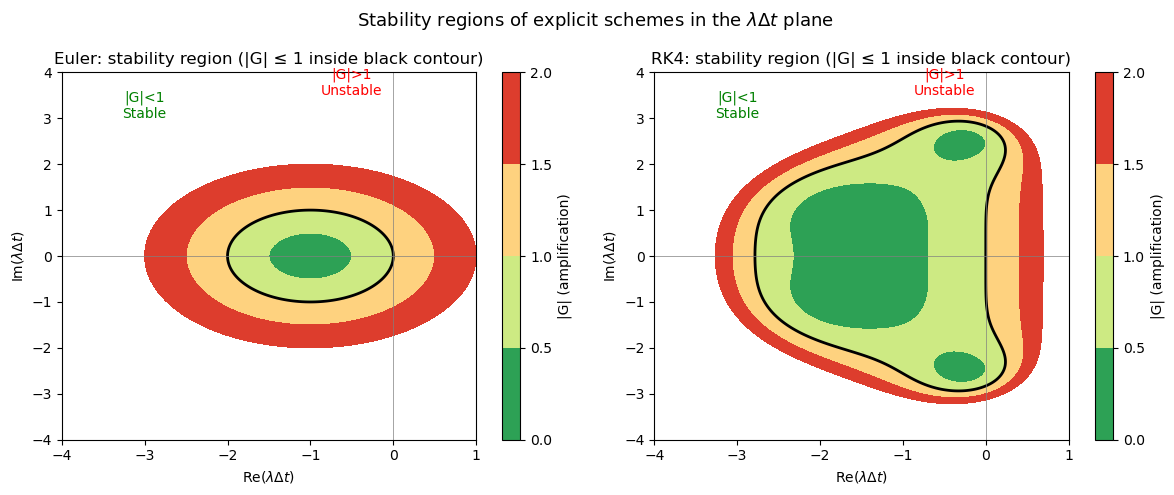

Diffusion eigenvalues are negative real → stay on left half-plane.
Advection eigenvalues are imaginary → need scheme with imaginary-axis coverage.


In [2]:
# Demonstration: stability regions of explicit time-stepping schemes
# For du/dt = lambda*u, scheme is stable if |G(lambda*dt)| <= 1

n = 300
x_lim, y_lim = 4, 4
re_vals = np.linspace(-x_lim, 1, n)
im_vals = np.linspace(-y_lim, y_lim, n)
RE, IM = np.meshgrid(re_vals, im_vals)
Z = RE + 1j*IM  # z = lambda*dt

# Amplification factors
G_euler = np.abs(1 + Z)
G_rk4   = np.abs(1 + Z + Z**2/2 + Z**3/6 + Z**4/24)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, G, title in zip(axes, [G_euler, G_rk4], ['Euler', 'RK4']):
    cf = ax.contourf(RE, IM, G, levels=[0, 0.5, 1.0, 1.5, 2.0], cmap='RdYlGn_r')
    ax.contour(RE, IM, G, levels=[1.0], colors='black', linewidths=2)
    plt.colorbar(cf, ax=ax, label='|G| (amplification)')
    ax.set_xlabel('Re($\\lambda \\Delta t$)'); ax.set_ylabel('Im($\\lambda \\Delta t$)')
    ax.set_title(f'{title}: stability region (|G| ≤ 1 inside black contour)')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.text(-3, 3, '|G|<1\nStable', ha='center', color='green', fontsize=10)
    ax.text(-0.5, 3.5, '|G|>1\nUnstable', ha='center', color='red', fontsize=10)

plt.suptitle('Stability regions of explicit schemes in the $\\lambda\\Delta t$ plane', fontsize=13)
plt.tight_layout()
plt.show()

print("Diffusion eigenvalues are negative real → stay on left half-plane.")
print("Advection eigenvalues are imaginary → need scheme with imaginary-axis coverage.")

## Key Takeaways

- Unsteady flows require time-accurate integration, not just a relaxation to steady state.
- Explicit schemes (Euler, RK4): simple, limited by CFL. Implicit (Crank-Nicolson, BDF2): stable at any $\Delta t$.
- For accuracy in unsteady flows: use at least 2nd-order time integration.
- Dual time-stepping: inner loop converges each physical time step using large pseudo-time steps.
- $Co < 1$ for explicit; $Co < 10$–50 for implicit (with accuracy check).
- OpenFOAM: `Euler` (1st, steady-state), `backward` (2nd, BDF2), `CrankNicolson 0.9` (implicit 2nd).

---

**Next**: Lesson 3.7 — Compressible Flow: Euler equations, Mach number, shock capturing.
